In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
print("Environment setup successful!")

Matplotlib is building the font cache; this may take a moment.


Environment setup successful!


In [2]:
# Load the dataset using your exact file name
df = pd.read_csv('mpc_train.csv')

# View the first 5 records
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
print("--- Data Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicates ---")
print(f"Total duplicate rows: {df.duplicated().sum()}")

# Summary statistics
df.describe().T

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  t

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [4]:
# Check for unrealistic zero values in physical dimensions
print("Rows where sc_w == 0:", (df['sc_w'] == 0).sum())
print("Rows where px_height == 0:", (df['px_height'] == 0).sum())

# Clean dataset by removing zero screen dimensions
df_clean = df[(df['sc_w'] > 0) & (df['px_height'] > 0)].copy()
print("Cleaned Dataset Shape:", df_clean.shape)

Rows where sc_w == 0: 180
Rows where px_height == 0: 2
Cleaned Dataset Shape: (1819, 21)


C:\Users\Vidushi\AppData\Local\Temp\ipykernel_30608\3243509935.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='price_range', palette='Set2')


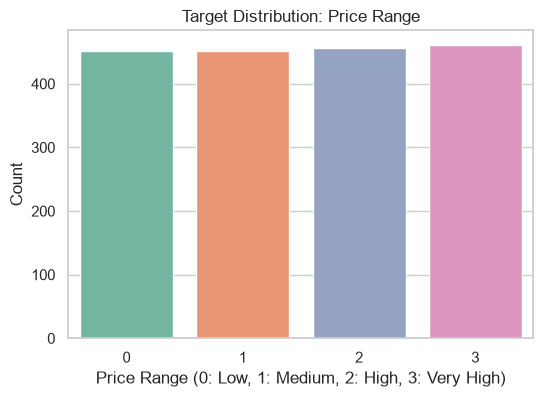

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='price_range', palette='Set2')
plt.title('Target Distribution: Price Range')
plt.xlabel('Price Range (0: Low, 1: Medium, 2: High, 3: Very High)')
plt.ylabel('Count')
plt.show()

C:\Users\Vidushi\AppData\Local\Temp\ipykernel_30608\846871461.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='price_range', y='ram', ax=axes[0], palette='Blues')
C:\Users\Vidushi\AppData\Local\Temp\ipykernel_30608\846871461.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='price_range', y='battery_power', ax=axes[1], palette='Greens')
C:\Users\Vidushi\AppData\Local\Temp\ipykernel_30608\846871461.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='price_range', y='px_height', ax=axes

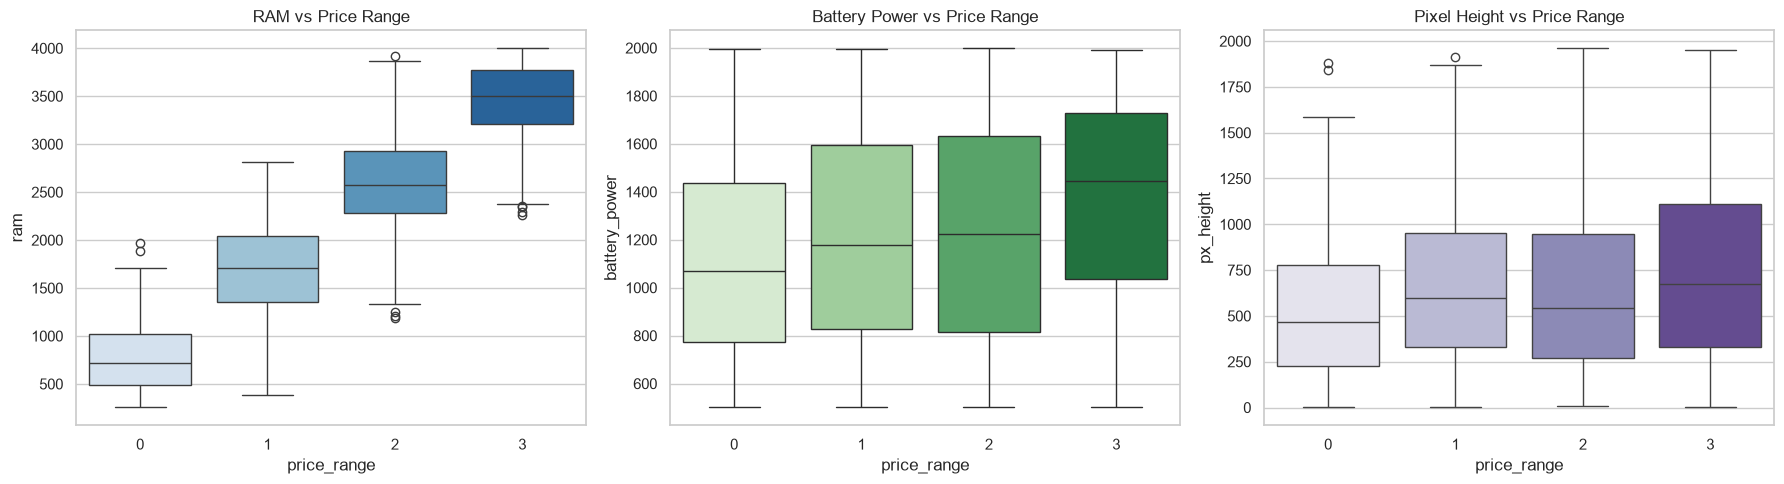

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_clean, x='price_range', y='ram', ax=axes[0], palette='Blues')
axes[0].set_title('RAM vs Price Range')

sns.boxplot(data=df_clean, x='price_range', y='battery_power', ax=axes[1], palette='Greens')
axes[1].set_title('Battery Power vs Price Range')

sns.boxplot(data=df_clean, x='price_range', y='px_height', ax=axes[2], palette='Purples')
axes[2].set_title('Pixel Height vs Price Range')

plt.tight_layout()
plt.show()

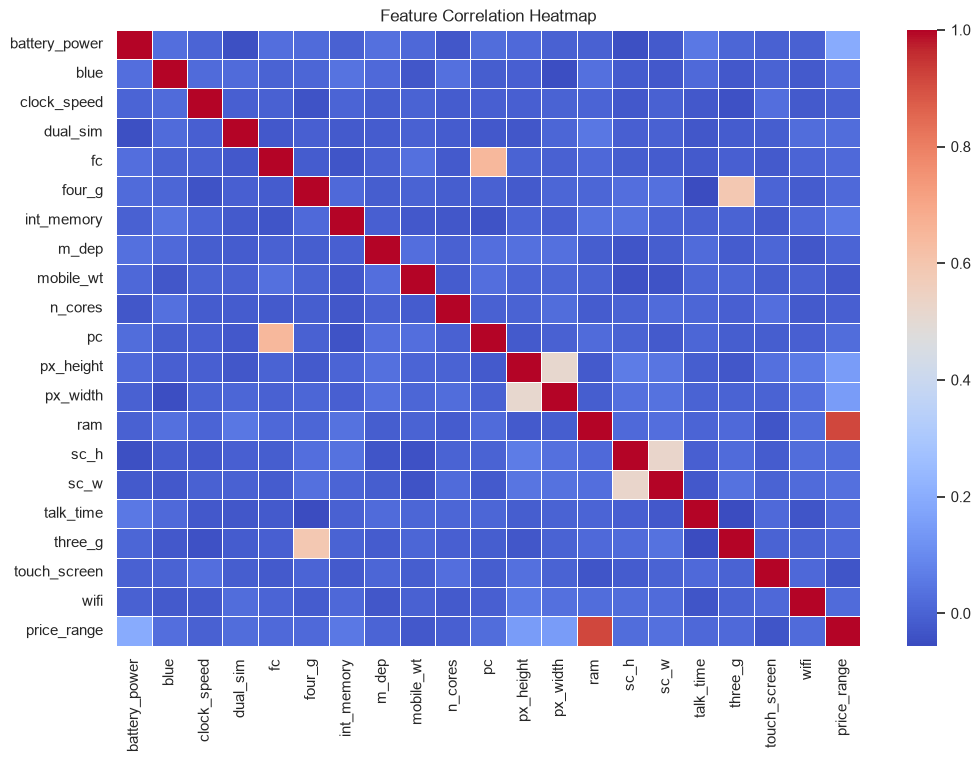

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clean.drop('price_range', axis=1)
y = df_clean['price_range']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing and split complete!")
print("Train set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Data preprocessing and split complete!
Train set shape: (1455, 20)
Test set shape: (364, 20)
